# Study 5: Continental Emissions Comparison

How do continents compare interm of average CO₂ per capita, and economic develeopemt?

### Objective:

This study compares average CO₂ per capita and GDP per capita across continents over the years.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modules.data_loader import DataLoader

## Load Preprocessed Data
We load 4 databases and merge into a single DataFrame with the following columns:
 `Continent`, `Country`, `year`, `co2`, `gdp`, `population`, `total_co2`, `total_gdp`

In [7]:
# Load the preprocessed CSV 
loader = DataLoader()            # Create an instance of the DataLoader class
data = loader.load_and_prepare_data()  # Call the method to load and clean the data
data.head()

,Continent,Country,year,co2,gdp,population,total_co2,total_gdp
0,Africa,Algeria,1800,0.0,763.0,2500000.0,0.0,1.907500e+09
1,Africa,Algeria,1801,0.0,764.0,2510000.0,0.0,1.917640e+09
2,Africa,Algeria,1802,0.0,765.0,2520000.0,0.0,1.927800e+09
3,Africa,Algeria,1803,0.0,766.0,2530000.0,0.0,1.937980e+09
4,Africa,Algeria,1804,0.0,767.0,2540000.0,0.0,1.948180e+09


## Plot: GDP, CO₂ emissions for continents (2020)
Visualizing the  GDP and CO₂ emissions per capita for continents:

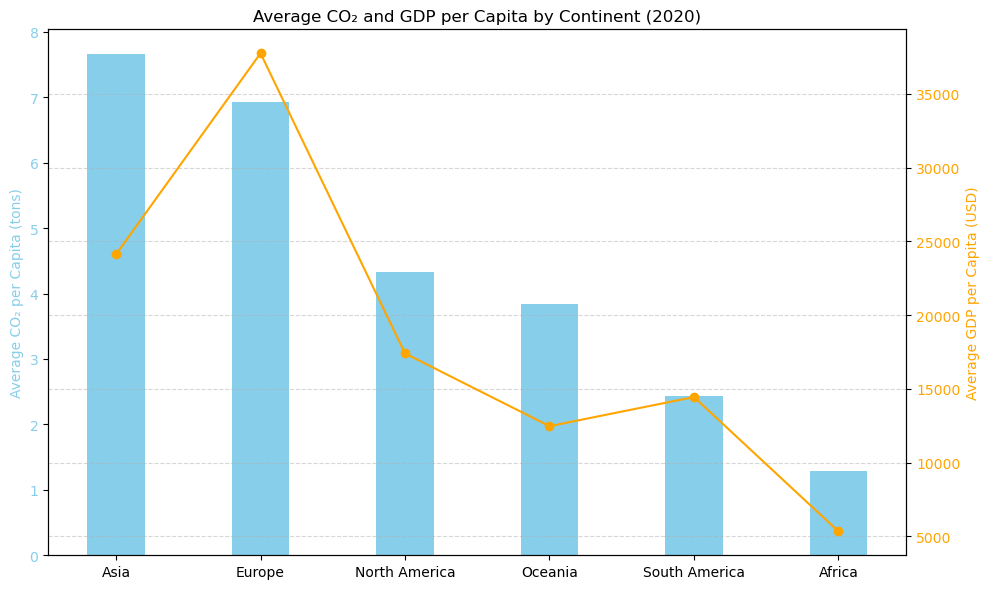

In [8]:
# Filter for selected countries and years
year = 2020
data_year = data[data["year"] == year]

# Drop rows with missing values
data_year = data_year.dropna(subset=["co2", "gdp"])

# Group by continent and calculate average CO₂ and GDP per capita
continent_summary = data_year.groupby("Continent")[["co2", "gdp"]].mean().sort_values("co2", ascending=False)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot CO₂ per capita
color1 = 'skyblue'
ax1.bar(continent_summary.index, continent_summary["co2"], color=color1, width=0.4, label="CO₂ per Capita")
ax1.set_ylabel("Average CO₂ per Capita (tons)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Add second Y-axis for GDP per capita
ax2 = ax1.twinx()
color2 = 'orange'
ax2.plot(continent_summary.index, continent_summary["gdp"], color=color2, marker='o', label="GDP per Capita")
ax2.set_ylabel("Average GDP per Capita (USD)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Title and layout
plt.title(f"Average CO₂ and GDP per Capita by Continent ({year})")
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

### Key Observations:

The average CO2 per capita and a line plot for average GDP per capita plot, reveals a general positive correlation between a continent's average economic output and its average carbon emissions per person. 

Europe exhibit the highest average GDP per capita, correspondingly showing second highest average CO2 emissions per capita.

However, for North America, while it has the third highest GDP and CO2 emissions, falling significantly below Europe and Asia.

Africa has by far the lowest average GDP per capita and, consistently, the lowest average CO2 per capita.

Asia, with a large and diverse population, shows the highest average CO2 per capita and lower average GDP per capita compared to Europe.
